In [125]:
import numpy as np
import matplotlib.pyplot as plt

### Q4
Write a simple accept-reject generator in python which can generate from an arbitary function of a random variable, f(X).

In [126]:
# x range
xrange = (-5,5)

# a
def func_a(x):
    return np.cos(x)**2

# b
def func_b(x):
    return np.sin(x) + np.cos(x) + 2

# c
def func_c(x):
    return ((np.sin(x) + np.cos(x))/(np.sinh(x) + np.cosh(x))) + 25

In [127]:
from scipy.optimize import brute

def f_neg(func):
    return lambda x: -func(x)

def find_ymax(func):
    x_opt = brute(f_neg(func), [xrange], finish=None)
    ymax = func(x_opt)
    print(f"y_max: {ymax:.2f}")
    return ymax

f_a_ymax = find_ymax(func_a)
f_b_ymax = find_ymax(func_b)
f_c_ymax = find_ymax(func_c)

y_max: 0.94
y_max: 3.41
y_max: 209.42


In [128]:
def gen_accept_reject(func, ymax, size):
    res = []
    while len(res)<size:
        a = np.random.uniform(*xrange)
        b = np.random.uniform(0,ymax)
        y = func(a)
        if y > ymax:
            print('Some issue: as y larger than ymax')
        if b <= y:
            res.append(a)
    return res

In [129]:
def plotter(func, ymax, size=5000):
    v = gen_accept_reject(func, ymax, size)
    x = np.linspace(*xrange, 200)
    y = func(x)
    y_scaled = y / np.trapezoid(y, x)

    plt.figure(figsize=(7,4))
    plt.hist(v, range=xrange, bins=50, density=True, alpha=0.5, label="Samples")
    plt.plot(x, y_scaled, 'r', label="Target pdf (scaled)")
    plt.title(f"Accept-Reject Sampling")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as

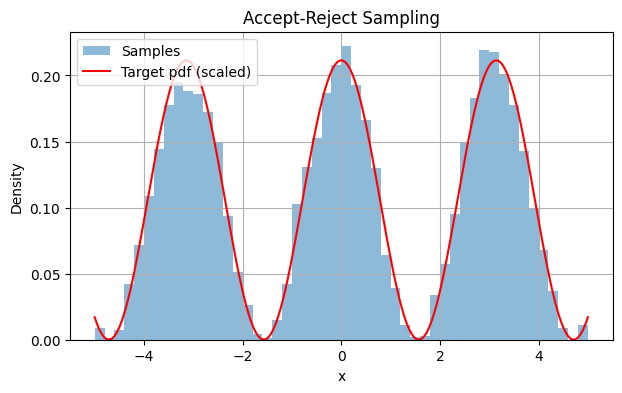

In [130]:
plotter(func_a, f_a_ymax)

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax


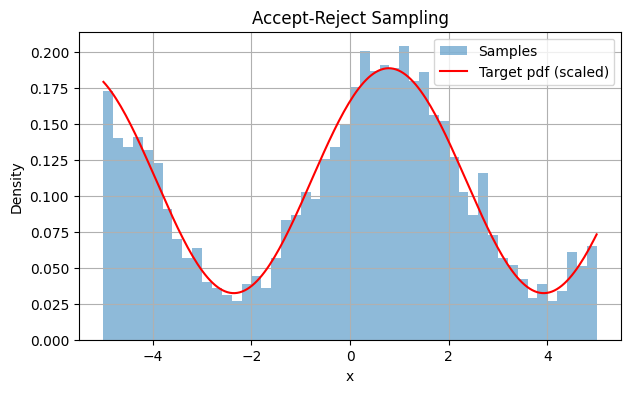

In [131]:
plotter(func_b, f_b_ymax)

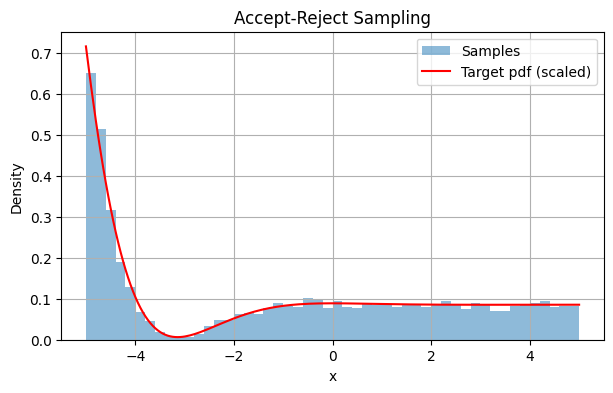

In [132]:
plotter(func_c, f_c_ymax)

Accept-reject generator in two-dimensions:
- Sample (x,y) from simple 2D dist
- Evaluate 2D target function
- Accept/reject in vertical dimension i.e., sample a height uniformly from [0,M], M = upper bound of target function -> accept if u <= f(x,y)

Accept-reject generator in two-dimensions:
- Sample x_hat = (x1, x2,..., xn) from n-dimensional dist
- Sample u ~ Uniform(0,M) where M bounds target density
- Accept if u <= f(x_hat)

Generation could be sped up by:
- Better proposal dist
    - Use a distribution q(x) that approximates the target function f(x) shape
    - Accept if u <= f(x) / (M*q(x)) where M is the bound on f(x)/q(x)
- Vectorisation and parallelisation
    - Generate many candidate samples at once
    - evaluate target func on all candidates simultaneously
    - Filter for accepted samples in one operation
- Early rejection
    - Use cheaper lower bound g(x) <= f(x)
    - Check u <= g(x); if false, reject without computing f(x)
    - Compute f(x) only if g(x) accepted

Generation efficiencies with 1D normal distribution (mu=0, sigma=1).

Plot of acceptance efficiency as a function of the generation range in terms of standard deviation.

incorrect solution below

In [ ]:
def standard_normal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

In [147]:
def acceptance_efficiency(func, x_range, ymax, n_trials):
    x_samples = np.random.uniform(x_range[0], x_range[1], n_trials)
    y_samples = np.random.uniform(0, ymax, n_trials)
    accepted = np.sum(y_samples <= func(x_samples))
    return accepted / n_trials

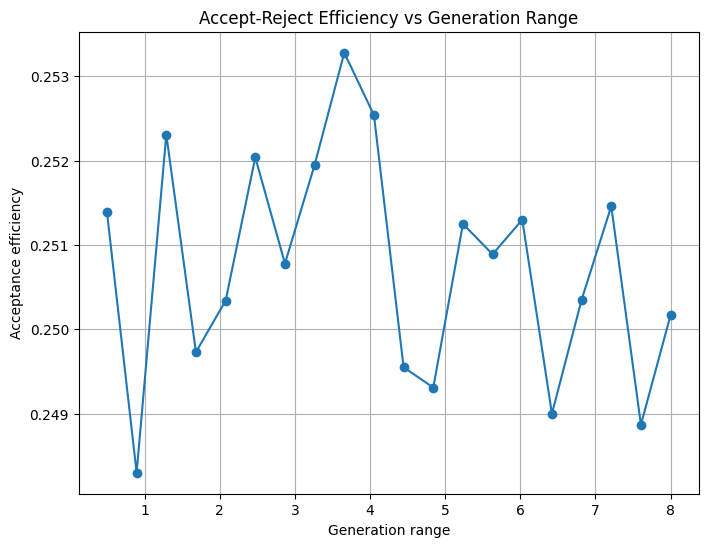

In [150]:
sigma_vals = np.linspace(0.5, 8, 20)
efficiencies = []

for val in sigma_vals:
    x_range = [-val, val]
    
    x_opt = np.linspace(*xrange, 1000)
    ymax = standard_normal_pdf(0)
    
    efficiency = acceptance_efficiency(standard_normal_pdf,
                                       xrange,
                                       ymax,
                                       n_trials=100000
                                       )
    efficiencies.append(efficiency)
    
plt.figure(figsize=(8,6))
plt.plot(sigma_vals, efficiencies, marker='o')
plt.title("Accept-Reject Efficiency vs Generation Range")
plt.xlabel("Generation range")
plt.ylabel("Acceptance efficiency")
plt.grid(True)
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def accept_reject(func, xrange, size, ymax=None):
    if ymax is None:
        x_test = np.linspace(xrange[0], xrange[1], 1000)
        ymax = np.max(func(x_test)) * 1.05
    
    samples = []
    attempts = 0
    
    while len(samples) < size:
        attempts += 1
        x = np.random.uniform(xrange[0], xrange[1])
        u = np.random.uniform(0, ymax)
        y = func(x)
        
        if y > ymax:
            ymax = y * 1.1
        
        if u <= y:
            samples.append(x)
            
    acceptance_rate = size / attempts
    return np.array(samples), acceptance_rate

In [7]:
def accept_reject_nd(func, xranges, size, ymax=None):
    n_dims = len(xranges)
    
    if ymax is None:
        n_grid = int(100 ** (1/n_dims))
        grids = [np.linspace(xr[0], xr[1], n_grid) for xr in xranges]
        mesh = np.meshgrid(*grids, indexing='ij')
        points = np.stack([m.ravel() for m in mesh], axis=1)
        ymax = np.max([func(p) for p in points]) * 1.05
    
    samples = []
    attempts = 0
    
    while len(samples) < size:
        attempts += 1
        x = np.array([np.random.uniform(xr[0], xr[1]) for xr in xranges])
        u = np.random.uniform(0, ymax)
        y = func(x)
        
        if u <= y:
            samples.append(x)
    
    acceptance_rate = size / attempts
    return np.array(samples), acceptance_rate

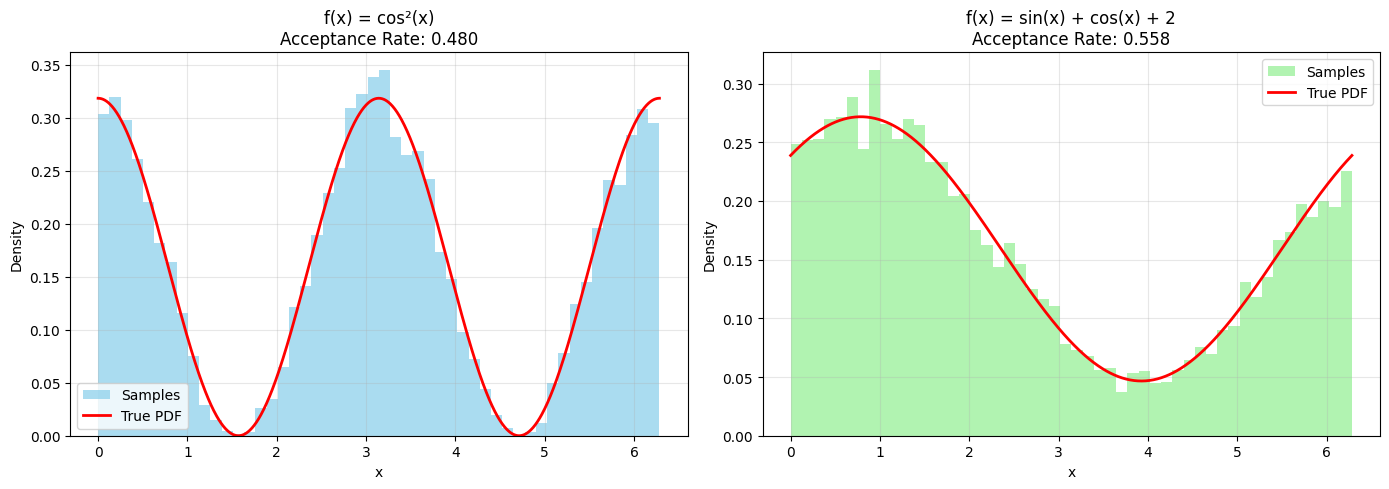

In [14]:
def func_b(x):
    return np.sin(x) + np.cos(x) + 2

def func_a(x):
    return np.cos(x) ** 2

xrange_a = (0, 2*np.pi)
samples_a, accept_rate_a = accept_reject(func_a, xrange_a, 10000)

xrange_b = (0, 2*np.pi)
samples_b, accept_rate_b = accept_reject(func_b, xrange_b, 10000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xa_plot = np.linspace(xrange_a[0], xrange_a[1], 1000)
ya_plot = func_a(xa_plot)
normalization_a = np.trapezoid(ya_plot, xa_plot)
y_a_plot_normalized = ya_plot / normalization_a

xb_plot = np.linspace(xrange_b[0], xrange_b[1], 1000)
yb_plot = func_b(xb_plot)
normalization_b = np.trapezoid(yb_plot, xb_plot)
y_b_plot_normalized = yb_plot / normalization_b

axes[0].hist(samples_a, bins=50, density=True, alpha=0.7, label='Samples', color='skyblue')
axes[0].plot(xa_plot, y_a_plot_normalized, 'r-', linewidth=2, label='True PDF')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title(f'f(x) = cos²(x)\nAcceptance Rate: {accept_rate_a:.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(samples_b, bins=50, density=True, alpha=0.7, label='Samples', color='lightgreen')
axes[1].plot(xb_plot, y_b_plot_normalized, 'r-', linewidth=2, label='True PDF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].set_title(f'f(x) = sin(x) + cos(x) + 2\nAcceptance Rate: {accept_rate_b:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
print(f"Part (a) - cos²(x): Acceptance Rate = {accept_rate_a:.4f}")
print(f"Part (b) - sin(x) + cos(x) + 2: Acceptance Rate = {accept_rate_b:.4f}")

Part (a) - cos²(x): Acceptance Rate = 0.4799
Part (b) - sin(x) + cos(x) + 2: Acceptance Rate = 0.5583



Standard Normal Acceptance Efficiency Analysis
Range: ±1.0σ, Acceptance Rate: 0.8475
Range: ±8.0σ, Acceptance Rate: 0.1637


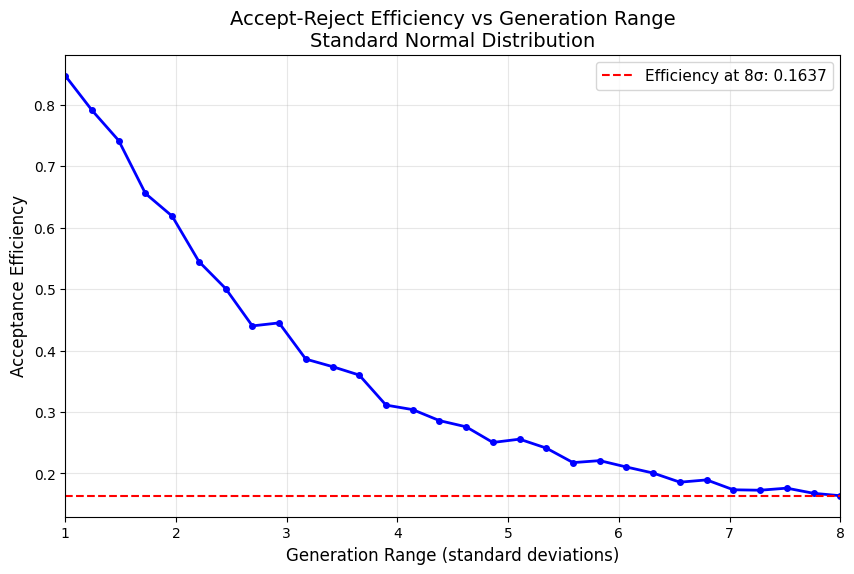


Approximate acceptance efficiency at ±8σ: 0.1637
This means only 16.37% of proposals are accepted!


In [16]:
def standard_normal(x):
    return np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)

sigma_ranges = np.linspace(1, 8, 30)
acceptance_rates = []

print("\n" + "="*60)
print("Standard Normal Acceptance Efficiency Analysis")
print("="*60)

for sigma_range in sigma_ranges:
    xrange = (-sigma_range, sigma_range)
    _, accept_rate = accept_reject(standard_normal, xrange, 1000, ymax=1/np.sqrt(2*np.pi))
    acceptance_rates.append(accept_rate)
    
    if sigma_range in [1, 2, 3, 4, 6, 8]:
        print(f"Range: ±{sigma_range:.1f}σ, Acceptance Rate: {accept_rate:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sigma_ranges, acceptance_rates, 'b-', linewidth=2, marker='o', markersize=4)
ax.axhline(y=acceptance_rates[-1], color='r', linestyle='--', 
           label=f'Efficiency at 8σ: {acceptance_rates[-1]:.4f}')
ax.set_xlabel('Generation Range (standard deviations)', fontsize=12)
ax.set_ylabel('Acceptance Efficiency', fontsize=12)
ax.set_title('Accept-Reject Efficiency vs Generation Range\nStandard Normal Distribution', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(1, 8)
plt.savefig('normal_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nApproximate acceptance efficiency at ±8σ: {acceptance_rates[-1]:.4f}")
print(f"This means only {acceptance_rates[-1]*100:.2f}% of proposals are accepted!")